In [3]:
import tensorflow
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dropout

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras.metrics import TopKCategoricalAccuracy

from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy

import numpy as np

# Dataset loading 

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 69s 0us/step


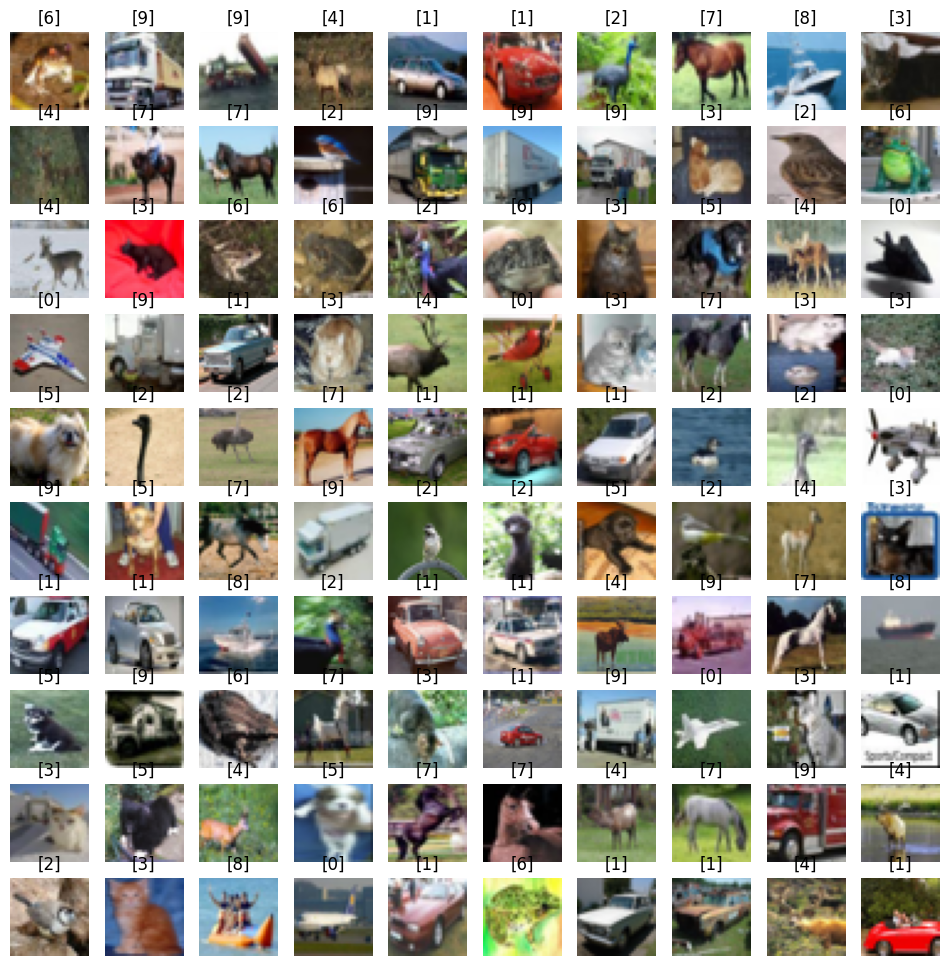

In [5]:
plt.figure(figsize=(12, 12))
for i in range(100):
    ax = plt.subplot(10, 10, i + 1)
    plt.imshow(np.array(x_train[i]))
    plt.title(str(y_train[i]))
    plt.axis("off")

# The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. 

In [6]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


# Dataset prepare

In [7]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [8]:
x_train[0]

array([[[ 59.,  62.,  63.],
        [ 43.,  46.,  45.],
        [ 50.,  48.,  43.],
        ...,
        [158., 132., 108.],
        [152., 125., 102.],
        [148., 124., 103.]],

       [[ 16.,  20.,  20.],
        [  0.,   0.,   0.],
        [ 18.,   8.,   0.],
        ...,
        [123.,  88.,  55.],
        [119.,  83.,  50.],
        [122.,  87.,  57.]],

       [[ 25.,  24.,  21.],
        [ 16.,   7.,   0.],
        [ 49.,  27.,   8.],
        ...,
        [118.,  84.,  50.],
        [120.,  84.,  50.],
        [109.,  73.,  42.]],

       ...,

       [[208., 170.,  96.],
        [201., 153.,  34.],
        [198., 161.,  26.],
        ...,
        [160., 133.,  70.],
        [ 56.,  31.,   7.],
        [ 53.,  34.,  20.]],

       [[180., 139.,  96.],
        [173., 123.,  42.],
        [186., 144.,  30.],
        ...,
        [184., 148.,  94.],
        [ 97.,  62.,  34.],
        [ 83.,  53.,  34.]],

       [[177., 144., 116.],
        [168., 129.,  94.],
        [179., 1

In [9]:
x_train = x_train / 255
x_test = x_test / 255

In [10]:
x_train[0]

array([[[0.23137255, 0.24313726, 0.24705882],
        [0.16862746, 0.18039216, 0.1764706 ],
        [0.19607843, 0.1882353 , 0.16862746],
        ...,
        [0.61960787, 0.5176471 , 0.42352942],
        [0.59607846, 0.49019608, 0.4       ],
        [0.5803922 , 0.4862745 , 0.40392157]],

       [[0.0627451 , 0.07843138, 0.07843138],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509805, 0.21568628],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117648, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215687, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941177, 0.19607843],
        [0.47058824, 0.32941177, 0.19607843],
        [0.42745098, 0.28627452, 0.16470589]],

       ...,

       [[0.8156863 , 0.6666667 , 0.3764706 ],
        [0.7882353 , 0.6       , 0.13333334],
        [0.7764706 , 0

In [11]:
x_train.min(), x_train.max()

(np.float32(0.0), np.float32(1.0))

In [12]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [13]:
y_train_cat = to_categorical(y_train)

In [14]:
y_train_cat[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [15]:
y_test_cat = to_categorical(y_test)
y_test_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

# Validation dataset prepartation

In [16]:
x_valid = x_train[40000:]
y_valid_cat = y_train_cat[40000:]

x_train = x_train[:40000]
y_train_cat = y_train_cat[:40000]

In [17]:
x_valid.shape

(10000, 32, 32, 3)

In [18]:
y_valid_cat.shape

(10000, 10)

In [19]:
x_train.shape

(40000, 32, 32, 3)

In [20]:
x_test.shape

(10000, 32, 32, 3)

# Training neural network

In [21]:

model = Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
#model.add(Activation("relu"))
model.add(MaxPooling2D(4, 4))

#model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
#model.add(BatchNormalization())
#model.add(MaxPooling2D(2, 2))
#model.add(Dropout(0.25))

#model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
#model.add(BatchNormalization())

#model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
#model.add(BatchNormalization())
#model.add(MaxPooling2D(2, 2))

# !!! Important to remind 
# sigmoid - from 0 to 1 (for 2 classes)
# softmax - from 0 to 1 (for 3 or more classes)

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


model.summary()
#plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,450 (4.02 MB)

 Trainable params: 1,053,322 (4.02 MB)

 Non-trainable params: 128 (512.00 B)

In [22]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=CategoricalCrossentropy(),
              metrics=['accuracy', TopKCategoricalAccuracy(k=2, name="Top2")])

In [25]:
history = model.fit(x_train, y_train_cat, batch_size=256, epochs = 20, validation_data=(x_valid, y_valid_cat))

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 463ms/step - Top2: 0.6016 - accuracy: 0.3870 - loss: 1.6775 - val_Top2: 0.7040 - val_accuracy: 0.5039 - val_loss: 1.4069
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 476ms/step - Top2: 0.7095 - accuracy: 0.5014 - loss: 1.3952 - val_Top2: 0.7521 - val_accuracy: 0.5559 - val_loss: 1.2485
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 467ms/step - Top2: 0.7489 - accuracy: 0.5534 - loss: 1.2724 - val_Top2: 0.7717 - val_accuracy: 0.5886 - val_loss: 1.1734
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 528ms/step - Top2: 0.7765 - accuracy: 0.5838 - loss: 1.1734 - val_Top2: 0.8003 - val_accuracy: 0.6214 - val_loss: 1.0791
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 449ms/step - Top2: 0.7914 - accuracy: 0.6024 - loss: 1.1194 - val_Top2: 0.8044 - val_accuracy: 0.6236 - val_loss: 1.0714
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 419ms/step - Top2: 0.8023 - accuracy: 0.6206 - loss: 1.0702 - val_Top2: 0.8201 - val_accuracy: 0.6481 - val_loss: 1.0190
Epoch 7/20

In [ ]:
model.save("cifar10.keras")

# Evaluation

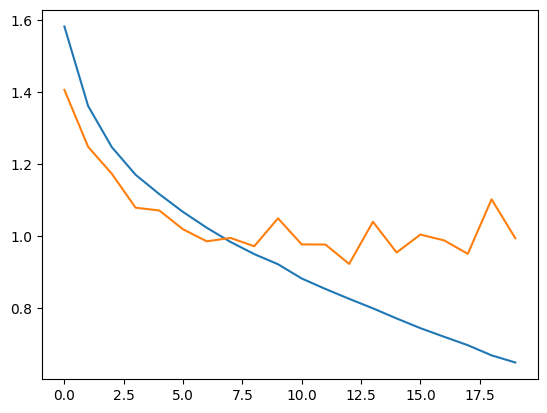

In [26]:
plt.plot(history.history['loss']);
plt.plot(history.history['val_loss']);

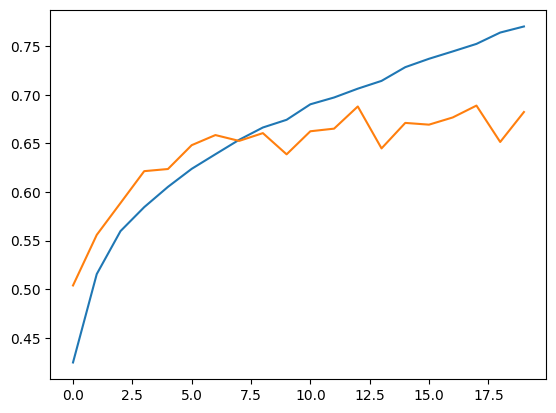

In [27]:
plt.plot(history.history['accuracy']);
plt.plot(history.history['val_accuracy']);

In [28]:
model.evaluate(x_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - Top2: 0.8346 - accuracy: 0.6733 - loss: 1.0247


[1.0188034772872925, 0.6777999997138977, 0.8342000246047974]

In [29]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [32]:
#Predict
y_prediction_cat = model.predict(x_test)
y_prediction = np.argmax(y_prediction_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [33]:
print(y_test.shape)
print(y_prediction_cat.shape)

(10000, 1)
(10000, 10)


In [34]:
#Create confusion matrix and normalizes it over predicted (columns)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_prediction, normalize='pred')
print(cm)

[[0.77083333 0.01778243 0.05039194 0.02352941 0.02564103 0.00252845
  0.01127396 0.02088353 0.10050251 0.056     ]
 [0.01967593 0.80543933 0.00895857 0.01029412 0.0021978  0.00505689
  0.00338219 0.0064257  0.03852596 0.11911111]
 [0.06481481 0.0083682  0.6237402  0.04117647 0.10915751 0.07079646
  0.05411499 0.04899598 0.02177554 0.00977778]
 [0.0162037  0.0167364  0.08846585 0.56911765 0.10915751 0.19216182
  0.06087937 0.06184739 0.03433836 0.02755556]
 [0.01851852 0.00313808 0.0537514  0.04264706 0.53846154 0.01896334
  0.04058625 0.07871486 0.01256281 0.00444444]
 [0.01851852 0.0041841  0.07054871 0.18529412 0.07252747 0.62326169
  0.0259301  0.10763052 0.02261307 0.01333333]
 [0.00694444 0.01569038 0.05711086 0.08382353 0.07765568 0.03539823
  0.79481398 0.00803213 0.01088777 0.008     ]
 [0.01388889 0.0041841  0.02799552 0.02941176 0.04835165 0.0391909
  0.00338219 0.64899598 0.00670017 0.02044444]
 [0.04282407 0.03242678 0.01231803 0.00441176 0.00952381 0.00632111
  0.0011274  

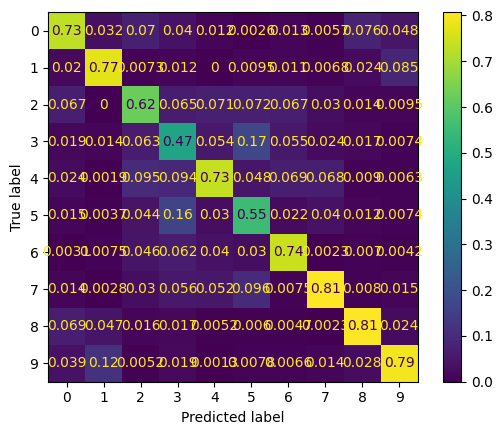

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
print(predictions.shape)
print(predictions[0])

(10000, 10)
[4.4241679e-04 1.9271510e-04 6.0964673e-04 9.8102945e-01 7.9102220e-04
 1.1306133e-02 6.0683081e-04 4.9675149e-05 4.6801083e-03 2.9194675e-04]


In [ ]:
import numpy as np
np.argmax(predictions[0])

3

In [ ]:
np.argmax(y_test[0])

0

In [ ]:
x_test.shape

(10000, 32, 32, 3)

Text(0.5, 1.0, 'Class: [3]')

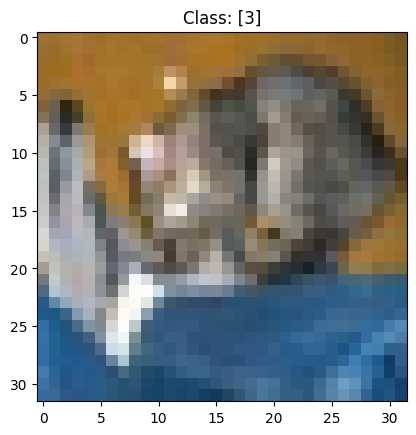

In [ ]:
plt.imshow(x_test[0])
plt.title('Class: ' + str(y_test[0]))